# Lab Tutorial: PyTorch Deep Dive

House Price Prediction using California Housing Dataset

## Step 1: Imports and Setup

First, let's import all the libraries we need and configure our environment.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


# Device configuration (use GPU if available; GPU for faster computation)
# `torch.cuda.is_available()` checks is GPU is available in the system
# `CUDA` is a parallel computing programming model to access NVIDIA GPUs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## Step 2: Load and Explore the California Housing Dataset

In [ ]:
housing = fetch_california_housing()
print(housing.data.shape, housing.target.shape)

# Explore the dataset structure
print("Dataset keys:", list(housing.keys()))
print("Feature names:", housing.feature_names)
print("Target names:", housing.target_names)
print("DESCRIPTION:", housing.DESCR)

(20640, 8) (20640,)
Dataset keys: ['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR']
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target names: ['MedHouseVal']
DESCRIPTION: .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
http

In [ ]:
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['target'] = housing.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
## Check is columns have missing values
print(data.isnull().sum())
print("""There are no missing values in the dataset. However, the scale of the features varies significantly, which
may affect the performance of machine learning models. Hence, we will be applying feature scaling techniques
such as normalization or standardization to improve model performance.""")

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64
There are no missing values in the dataset. However, the scale of the features varies significantly, which
may affect the performance of machine learning models. Hence, we will be applying feature scaling techniques
such as normalization or standardization to improve model performance.


### Some preprocessing

In [ ]:
## Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

## Normalize the features using standardization (zero mean and unit variance)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

## We fit the scaler on the training data and use the statistics for train set to transform the validation and test sets to prevent data leakage
## As in ideal situation, we never know the test set.
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Converting data to PyTorch Tensors

PyTorch works with its own data structure called **Tensors**, which are similar to NumPy arrays but can be used on GPUs for faster computation.

Here we simply convert our NumPy arrays to PyTorch tensors and move them to the device (CPU or GPU).

In [ ]:
## Convert NumPy arrays to PyTorch tensors

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

print(f'Training set: X shape = {X_train_tensor.shape}, y shape = {y_train_tensor.shape}')
print(f'Validation set: X shape = {X_val_tensor.shape}, y shape = {y_val_tensor.shape}')
print(f'Test set: X shape = {X_test_tensor.shape}, y shape = {y_test_tensor.shape}')
print(f'\nSample feature vector: {X_train_tensor[0]}')
print(f'Sample target value: {y_train_tensor[0]}')

Training set: X shape = torch.Size([12384, 8]), y shape = torch.Size([12384])
Validation set: X shape = torch.Size([4128, 8]), y shape = torch.Size([4128])
Test set: X shape = torch.Size([4128, 8]), y shape = torch.Size([4128])

Sample feature vector: tensor([-0.7955,  0.8260, -0.7169, -0.2041, -0.0204,  0.1019, -0.5688, -0.0450],
       device='cuda:0')
Sample target value: 2.4140000343322754


## Step 3: Building a Linear Regression Model in PyTorch

Following is the basic syntax of defining models in PyTorch

```
class SomeMLModel(nn.Module):
    def __init__(self, some_hyper_parameter_1, some_hyper_parameter_2):
        ### Here we create some layers for the model

    def forward(self, x):
        ### Here we define the order of the flow of data from layers
        ### layers
```

In [ ]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel(input_dim=X_train_scaled.shape[1])
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
## Inspect the model parameters
print("Model parameters:")
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")
    print(f"  Values: {param.data}")
## Move the model to GPU device
print("Moving to GPU...")
model.to(device)
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")
    print(f"  Values: {param.data}")

Model parameters:
linear.weight: torch.Size([1, 8])
  Values: tensor([[ 0.2312, -0.1629, -0.2411,  0.0854,  0.3367,  0.1103, -0.2843,  0.1629]])
linear.bias: torch.Size([1])
  Values: tensor([0.1244])
Moving to GPU...
linear.weight: torch.Size([1, 8])
  Values: tensor([[ 0.2312, -0.1629, -0.2411,  0.0854,  0.3367,  0.1103, -0.2843,  0.1629]],
       device='cuda:0')
linear.bias: torch.Size([1])
  Values: tensor([0.1244], device='cuda:0')


## Step 4: Define the Loss Function and Optimizer

As discussed in previous classes, we used Gradient Descent for training. And for performing Gradient Descent we need a loss function.

PyTorch provides pre-built functions and classes for most Loss functions and performing gradient descent. We will use MSELoss (as it is a regression task)
and **Stochastic Gradient Descent** provided as `optimizer` objects in PyTorch instead of analytically implementing it.

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001) ## Performs Gradient Descent

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")


Loss function: MSELoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## Step 5: Training the Model

The training loop is the heart of deep learning. In each **epoch** (one pass through the entire dataset):

1. **Forward pass**: Compute predictions
2. **Calculate loss**: Compare predictions with true labels and compute loss, $\mathcal{L}$
3. **Backward pass**: Compute gradients,  $\nabla_{\theta} \mathcal{L}$,  via backpropagation (`loss.backward()`). PyTorch does it for us.
4. **Update weights**: Apply the optimizer (`optimizer.step()`). This updates the parameters: $\theta_{t+1} = \theta_{t} - \eta \nabla_{\theta_{t}} \mathcal{L}$
5. **Zero gradients**: Reset for the next iteration (`optimizer.zero_grad()`). PyTorch stores the gradients when we call `loss.backward()`. We need to make it 0 so that it does not add to the gradients of next iteration of gradient descent

We also track the training loss over epochs so we can visualize the learning curve.

In [ ]:
num_epochs = 1000
train_losses = []
val_losses = []

print('Starting Training...')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>10}')
print('-' * 35)

# Initially, model is not trained and we set the best validation loss to infinity. We will select the model with the lowest validation loss as the best model.
best_val_loss = float('inf')
for epoch in range(num_epochs):
    model.train()  # Set model to training mode

    # Zeroing the gradients before hand
    optimizer.zero_grad()

    # Forward pass — pass the entire training set at once
    outputs = model(X_train_tensor)
    outputs = outputs.squeeze()
    ## We need to squeeze because the model takes input in shape (num_samples, num_features) and outputs in shape (num_samples, 1).
    ## But, our ground truth values `y_train_tensor` are in shape (num_samples,). So, we need to squeeze the output to match the shape of the target.
    train_loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    train_loss.backward()
    optimizer.step()

    ## Validation
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # No need to track gradients for validation
        val_outputs = model(X_val_tensor)
        val_outputs = val_outputs.squeeze()
        val_loss = criterion(val_outputs, y_val_tensor)
    ## What is torch.no_grad()?
    ## Whenever we perform operations on tensors returned via the model, PyTorch tracks these operations to compute gradients during backpropagation.
    ## And this tracking also needs memory. So, when we perform operations that don't need gradients, we can wrap them in `torch.no_grad()` to save memory,
    ## computations and interference with gradient computation.

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'{epoch+1:>6} | {train_loss.item():>10.4f} | {val_loss.item():>10.4f}')

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
        ## `model.state_dict()` returns a dictionary containing the model's parameters.

print('\nFinished Training! ')
print(f'Best validation loss: {best_val_loss:.4f}')

Starting Training...
 Epoch | Train Loss |   Val Loss
-----------------------------------
     1 |     5.3297 |     5.5339
     5 |     5.2488 |     5.4480
    10 |     5.1497 |     5.3429
    15 |     5.0528 |     5.2403
    20 |     4.9581 |     5.1400
    25 |     4.8656 |     5.0420
    30 |     4.7750 |     4.9462
    35 |     4.6866 |     4.8527
    40 |     4.6000 |     4.7613
    45 |     4.5154 |     4.6719
    50 |     4.4327 |     4.5846
    55 |     4.3518 |     4.4993
    60 |     4.2727 |     4.4159
    65 |     4.1954 |     4.3344
    70 |     4.1197 |     4.2548
    75 |     4.0458 |     4.1769
    80 |     3.9734 |     4.1008
    85 |     3.9026 |     4.0264
    90 |     3.8334 |     3.9536
    95 |     3.7657 |     3.8825
   100 |     3.6995 |     3.8129
   105 |     3.6347 |     3.7449
   110 |     3.5713 |     3.6785
   115 |     3.5093 |     3.6134
   120 |     3.4486 |     3.5499
   125 |     3.3893 |     3.4877
   130 |     3.3312 |     3.4269
   135 |     3.2744

### Visualizing the training progress

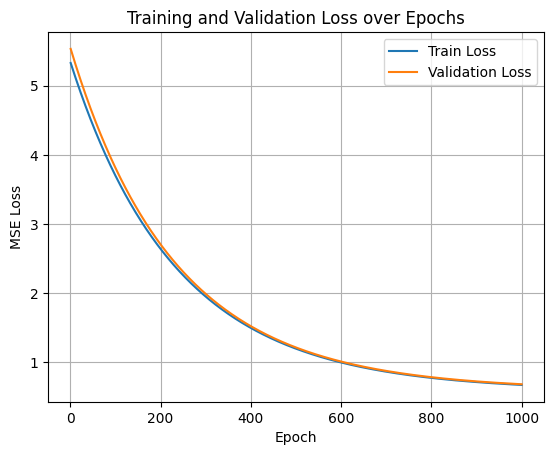

In [ ]:
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid()
plt.show()

## Step 8: Evaluating the Model on the Test Set

In [ ]:
## load the best model that we saved during training
best_model = LinearRegressionModel(input_dim=X_train_scaled.shape[1])
best_model_state_dict = torch.load('best_model.pth')
best_model.load_state_dict(best_model_state_dict)
best_model.to(device)
best_model.eval()  # Set model to evaluation mode

with torch.no_grad():
    test_outputs = best_model(X_test_tensor)
    test_outputs = test_outputs.squeeze()
    test_loss = criterion(test_outputs, y_test_tensor)

print(f'Test MSE: {test_loss.item():.4f}')


Test MSE: 0.6806


In [ ]:
## Pick some random samples from the test set and compare the predicted values with the actual values
num_samples = 10
random_indices = np.random.choice(len(X_test_tensor), num_samples, replace=False)
x_samples = X_test_tensor[random_indices]
y_samples = y_test_tensor[random_indices]

with torch.no_grad():
    predictions = best_model(x_samples).squeeze()
    predictions = predictions.cpu()

data = {
    "Ground_truth": y_samples.cpu(), "Predictions": predictions
}

data = pd.DataFrame(data)
data

,Ground_truth,Predictions
0,1.343,1.304813
1,2.552,1.799198
2,3.147,2.430419
3,2.245,1.578219
4,2.348,1.949365
5,1.456,1.689532
6,1.557,1.526128
7,0.840,1.823703
8,2.380,1.653330
9,0.725,0.946482


The performance seems average. But, note that the unit of the target variable is in $100,000. So an error of 0.67 is still a lot.
So, ideally, we should so much better than this.

## Exercises
---
```
# Exercise 1: Create a baseline logistic regression model on the Breast Cancer dataset
`from sklearn.datasets import load_breast_cancer`
Load the dataset and perform feature scaling using `StandardScaler`.
Perform an 80-20 train-test split.
Train a baseline model using sklearn's `LogisticRegression` and calculate the accuracy on the test set.
```
```
# Exercise 2: Implement Logistic Regression using PyTorch
Using the scaled breast cancer data from Exercise 1, build a PyTorch model to classify the tumors (malignant vs. benign).
Complete the following steps:

1. Convert the numpy arrays to PyTorch tensors (ensure targets are reshaped properly).
2. Create a custom `nn.Module` with a single linear layer.
3. Set up the loss function (`nn.BCEWithLogitsLoss()`) and optimizer (`optim.SGD()`).
4. Write a training loop for 100 epochs.
5. Evaluate the model on the test set, calculate the accuracy, and compare it with the sklearn baseline.

```